<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/Copy_of_P9_Detector_Wajah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pada tahap ini, kita akan membuat detektor wajah dengan algoritma Haar Cascade. Berikut merupakan beberapa tahapan yang akan Anda lakukan dalam proyek ini:

1. Pilihlah gambar untuk dideteksi. Karena kita akan mendeteksi wajah, tentu gambar yang dipilih harus ada wajahnya ya!

2. Unduh dan load Haar cascades fitur dari repositori GitHub OpenCV.

3. Panggil fungsi classifier untuk mendeteksi wajah.

4. Tambahkan kotak deteksi pada area wajah.



Untuk menerapkan Haar Cascade pada proyek deteksi wajah, Anda perlu menginstal library opencv terlebih dahulu. OpenCV menyediakan ratusan algoritma computer vision yang dapat digunakan secara mudah & gratis oleh para developer. Opencv juga menyediakan berbagai metoda pelatihan atau pre-trained model untuk deteksi objek (Cascade Classifier Training) yang bisa dibaca menggunakan teknik CascadeClassifier.load. Pre-trained model berlokasi di folder data pada repositori GitHub OpenCV.

In [ ]:
import gdown
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams['figure.figsize'] = [15, 30]

In [ ]:
# URL file yang akan diunduh
file_url = 'https://drive.google.com/u/0/uc?id=1uzEdXmWbW6y65jgOhSNfIiAib-hyEA9O&export=download'

# Path tempat Anda ingin menyimpan file yang diunduh
path = '/content/sample_data/image.jpg'

gdown.download(file_url, path, quiet=False)


Downloading...
From: https://drive.google.com/u/0/uc?id=1uzEdXmWbW6y65jgOhSNfIiAib-hyEA9O&export=download
To: /content/sample_data/image.jpg
100%|██████████| 268k/268k [00:00<00:00, 53.1MB/s]


'/content/sample_data/image.jpg'

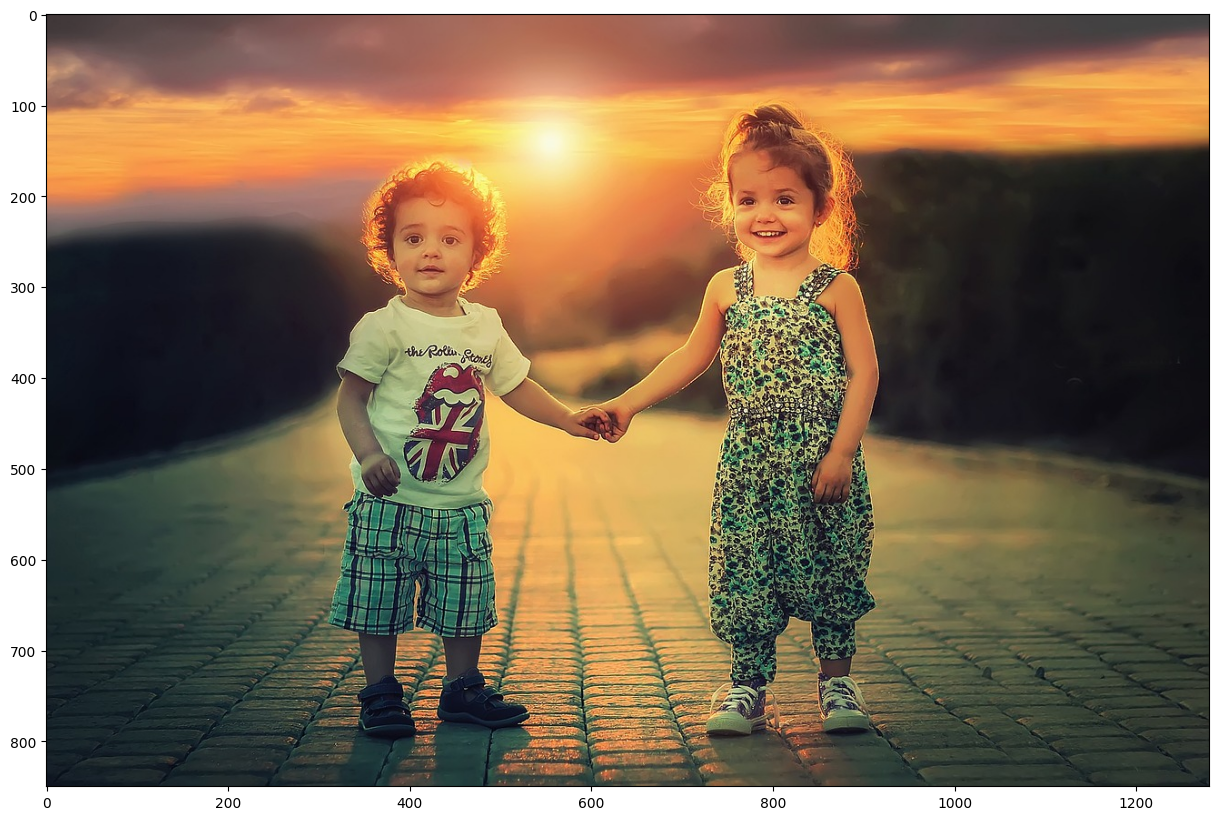

In [ ]:
img = cv2.imread(path)

#ubah gambar menjadi RGB
imgrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(imgrgb)
plt.show()

In [ ]:
!wget "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml" -O haarcascade_frontalface_default.xml


--2023-07-28 07:28:47--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.007s  

2023-07-28 07:28:47 (122 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]



In [ ]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

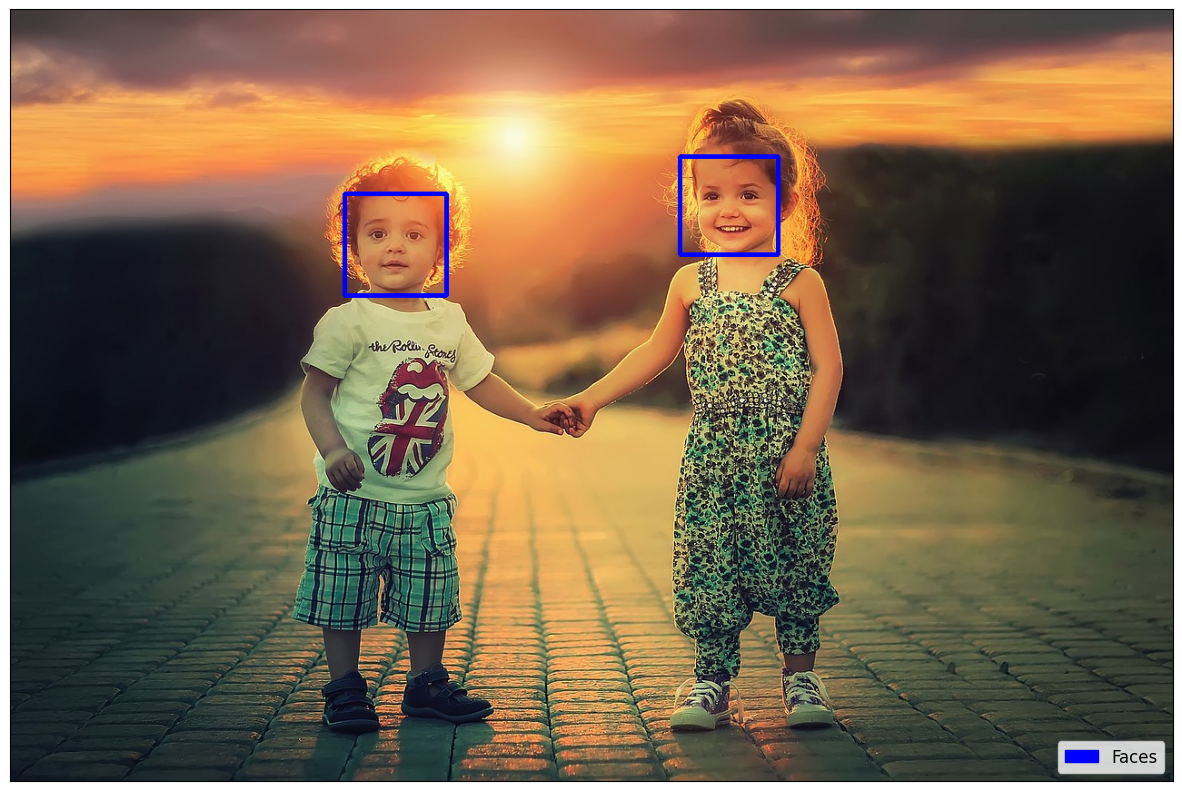

In [ ]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor = 1.3,
    minNeighbors = 5
    )

for(x, y, w, h) in faces:
    img = cv2.rectangle(
        img,          # objek gambar
        (x,y),        # posisi kotak
        (x+w,y+h),    # posisi kotak
        (255,0,0),    # warna kotak
        3             # lebar garis kotak
        )
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

plt.xticks([])
plt.yticks([])

# Membuat keterangan label
face_patch = mpatches.Patch(color='blue', label='Faces')
plt.legend(handles=[face_patch],
           loc='lower right', fontsize=12)

# Plot gambar
imgplot = plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [ ]:
# Face detector
!wget "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml" -O haarcascade_frontalface_default.xml

# Eye detector
!wget "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml" -O haarcascade_eye.xml

# Smile detector
!wget "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_smile.xml" -O haarcascade_smile.xml

--2023-07-28 07:36:05--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.01s   

2023-07-28 07:36:05 (81.2 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]

--2023-07-28 07:36:05--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... c

In [ ]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')


img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

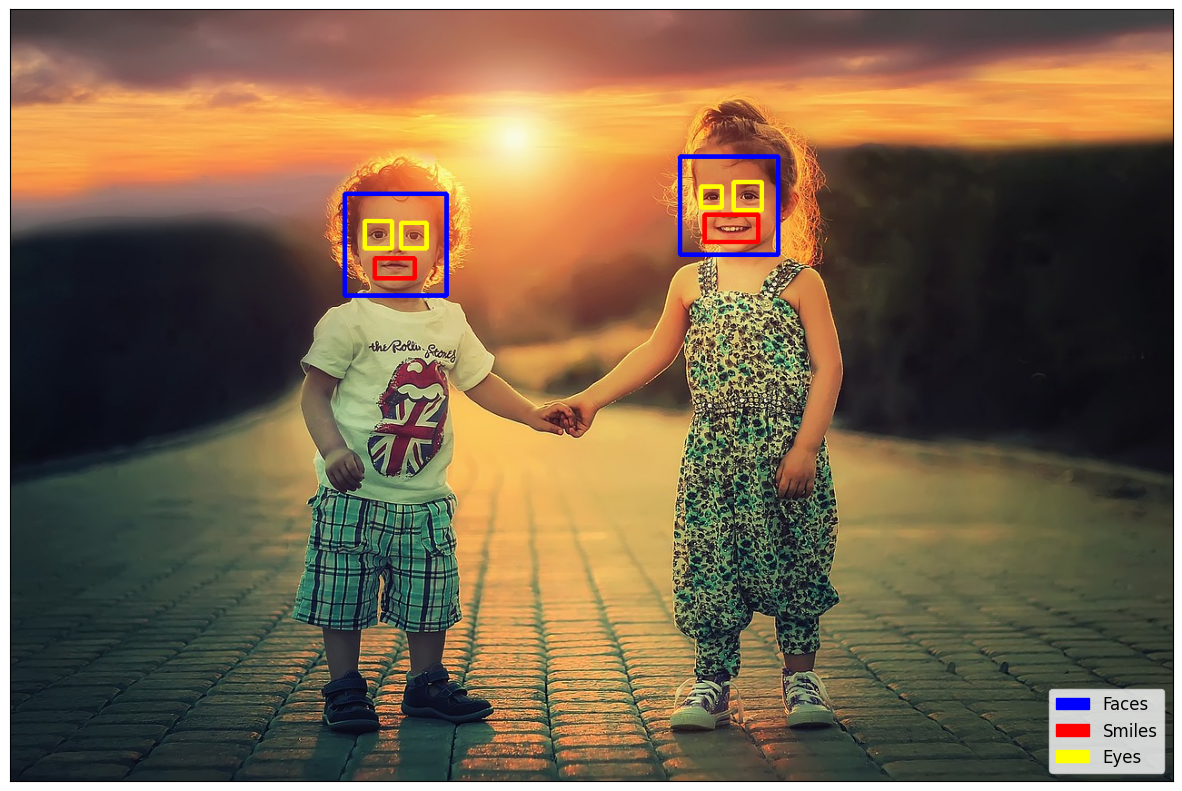

In [ ]:
faces =  face_cascade.detectMultiScale(
    gray,
    scaleFactor = 1.3,
    minNeighbors = 5
    )

for(x, y, w, h) in faces:
    img = cv2.rectangle(
        img,          # objek gambar
        (x,y),        # posisi awal kotak (horizontal dan vertikal)
        (x+w,y+h),    # posisi kotak dengan penambahan lebar (w) dan tinggi (h)
        (255,0,0),    # warna kotak dalam RGB
        3             # lebar garis kotak
        )

    # Mengatur region of interest (ROI) sebagai area target
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    smiles = smile_cascade.detectMultiScale(roi_gray, minNeighbors=20)
    for(sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx,sy), (sx+sw,sy+sh), (0,0,255), 3)

    eyes = eye_cascade.detectMultiScale(roi_gray)
    for(ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex,ey), (ex+ew,ey+eh), (0,255,255), 3)

plt.xticks([])
plt.yticks([])

face_patch = mpatches.Patch(color='blue', label='Faces')
smile_patch = mpatches.Patch(color='red', label='Smiles')
eye_patch = mpatches.Patch(color='yellow', label='Eyes')
plt.legend(handles=[face_patch, smile_patch, eye_patch],
           loc='lower right', fontsize=12)

imgplot = plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
